 Аналитическое решение:
x оптимальный:  [0.478 0.134 0.388]
y оптимальный:  [0.119 0.567 0.313]
Цена игры:  8.03
 Решение методом Брауна–Робинсона
|  N  | x_cur | y_cur | x potential | y potential |  up cost | low cost |
|-----|-------|-------|-------------|-------------|----------|----------|
|   1 |    0  |    0  | [13.  7.  8.] | [13.  2.  4.] |     13.0 |      2.0 |
|   2 |    0  |    1  | [15. 13. 22.] | [26.  4.  8.] |     11.0 |      2.0 |
|   3 |    2  |    1  | [17. 19. 36.] | [34. 18. 14.] |     12.0 |  4.66667 |
|   4 |    2  |    2  | [21. 29. 42.] | [42. 32. 20.] |     10.5 |      5.0 |
|   5 |    2  |    2  | [25. 39. 48.] | [50. 46. 26.] |      9.6 |      5.2 |
|   6 |    2  |    2  | [29. 49. 54.] | [58. 60. 32.] |      9.0 |  5.33333 |
|   7 |    2  |    2  | [33. 59. 60.] | [66. 74. 38.] |  8.57143 |  5.42857 |
|   8 |    2  |    2  | [37. 69. 66.] | [74. 88. 44.] |    8.625 |      5.5 |
|   9 |    1  |    2  | [41. 79. 72.] | [81. 94. 54.] |  8.77778 |      6.0 |
|  

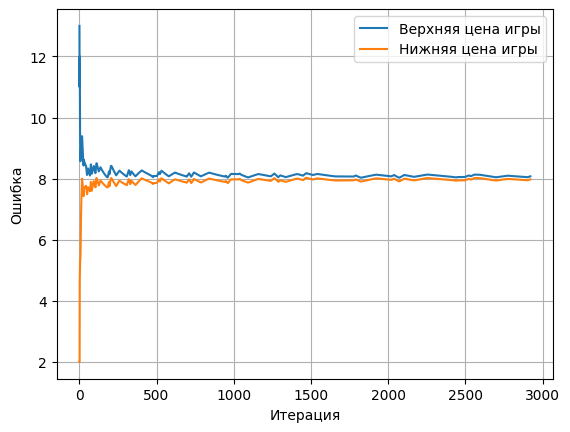

Итераций:  2920
 Итерационное решение:
x оптимальный:  [0.482 0.128 0.39 ]
y оптимальный:  [0.109 0.57  0.321]
Верхняя цена игры:  8.077
Нижняя цена игры:  7.977


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def solve_matrix_game_brown_robinson(c_matrix_in, epsilon = 0.1):

    c_matrix = np.array(c_matrix_in, dtype=float)

    c_matrix

    x_vector_length = c_matrix.shape[0]
    y_vector_length = c_matrix.shape[1]

    if(x_vector_length < 1 or y_vector_length < 1):
        raise ValueError("Некорректная матрица")

    x_vector = np.zeros(x_vector_length)
    y_vector = np.zeros(y_vector_length)

    x_current = 0
    y_current = 0

    x_vector[x_current] += 1
    y_vector[y_current] += 1

    x_potential = np.zeros(x_vector_length)
    y_potential = np.zeros(y_vector_length)

    iteration = 1

    # Первая итерация
    x_potential = x_potential + c_matrix.T[y_current]
    y_potential = y_potential + c_matrix[x_current]

    up_cost = max(x_potential / iteration)
    low_cost = min(y_potential / iteration)

    up_cost_array = []
    up_cost_array.append(up_cost)
    low_cost_array = []
    low_cost_array.append(low_cost)

    print(" Решение методом Брауна–Робинсона")
    print("|  N  | x_cur | y_cur | x potential | y potential |  up cost | low cost |")
    print("|-----|-------|-------|-------------|-------------|----------|----------|")
    print(f"| {iteration:3} |  {x_current:3}  |  {y_current:3}  | {x_potential} | {y_potential} | {round(up_cost, 5):8} | {round(low_cost, 5):8} |")

    # Итерируем, пока точность меньше нужной
    while( abs(up_cost - low_cost) > epsilon):
        iteration += 1

        x_current = x_potential.argmax()
        y_current = y_potential.argmin()

        x_vector[x_current] += 1
        y_vector[y_current] += 1

        x_potential = x_potential + c_matrix.T[y_current]
        y_potential = y_potential + c_matrix[x_current]

        up_cost = max(x_potential / iteration)
        low_cost = min(y_potential / iteration)

        up_cost_array.append(up_cost)
        low_cost_array.append(low_cost)

        if(iteration < 200):
            print(f"| {iteration:3} |  {x_current:3}  |  {y_current:3}  | {x_potential} | {y_potential} | {round(up_cost, 5):8} | {round(low_cost, 5):8} |")

    x_vector_optimal = x_vector / iteration
    y_vector_optimal = y_vector / iteration

    plt.plot(range(1,iteration+1),up_cost_array, label="Верхняя цена игры")
    plt.plot(range(1,iteration+1),low_cost_array, label="Нижняя цена игры")
    plt.xlabel("Итерация")
    plt.ylabel("Ошибка")
    plt.title = "Итерационный метод"
    plt.legend()
    plt.grid()
    plt.show()

    print("Итераций: ", iteration)

    return y_vector_optimal, x_vector_optimal, up_cost, low_cost

def solve_matrix_game_inverse_matrix(c_matrix_in):

    c_matrix = np.array(c_matrix_in, dtype=float)

    if c_matrix.shape[0] != c_matrix.shape[1]:
        raise ValueError("Матрица должна быть квадратной")
    
    c_matrix_inverse = np.linalg.inv(c_matrix)

    u_vector = np.ones(c_matrix.shape[0])
    
    x_opt = np.dot(c_matrix_inverse, u_vector.T) / ( np.dot( np.dot(u_vector, c_matrix_inverse), u_vector.T ) )
    y_opt = np.dot(u_vector, c_matrix_inverse)   / ( np.dot( np.dot(u_vector, c_matrix_inverse), u_vector.T ) )

    v_opt = 1. / ( np.dot( np.dot(u_vector, c_matrix_inverse), u_vector.T ) )

    return x_opt, y_opt, v_opt

if __name__ == "__main__":
    # Вариант 16
    C_matrix = [
        [13,  2, 4],
        [7,  6,  10],
        [8, 14, 6]
    ]

    x_optimal_1, y_optimal_1, v_optimal_1 = solve_matrix_game_inverse_matrix(C_matrix)

    print(" Аналитическое решение:")
    print("x оптимальный: ", x_optimal_1.round(3))
    print("y оптимальный: ", y_optimal_1.round(3))
    print("Цена игры: ", round(v_optimal_1,3))
    
    x_optimal_2, y_optimal_2, v_optimal_up_2, v_optimal_low_2 = solve_matrix_game_brown_robinson(C_matrix)

    print(" Итерационное решение:")
    print("x оптимальный: ", x_optimal_2.round(3))
    print("y оптимальный: ", y_optimal_2.round(3))
    print("Верхняя цена игры: ", round(v_optimal_up_2,3))
    print("Нижняя цена игры: ", round(v_optimal_low_2,3))

